In [2]:
import pandas as pd
import numpy as np
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = {
    "category": [
        "tech",
        "sport",
        "business",
        "entertainment",
        "politics",
        "tech",
        "sport",
        "business",
        "entertainment",
        "politics"
    ],

    "text": [
        "Apple launched a new AI powered iPhone with advanced camera features.",
        "India defeated Australia in the cricket world cup final.",
        "The stock market gained points after positive economic growth.",
        "The famous actor announced the release of his new movie.",
        "The government introduced a new education policy in parliament.",
        "Google introduced a powerful artificial intelligence search engine.",
        "The football team won the national championship after a thrilling match.",
        "Several companies reported higher profits during the last financial quarter.",
        "The music festival attracted thousands of fans from different countries.",
        "The prime minister addressed the nation about economic reforms."
    ]
}

df = pd.DataFrame(data)

print(df.head())

        category                                               text
0           tech  Apple launched a new AI powered iPhone with ad...
1          sport  India defeated Australia in the cricket world ...
2       business  The stock market gained points after positive ...
3  entertainment  The famous actor announced the release of his ...
4       politics  The government introduced a new education poli...


In [5]:
df.info()

df.isnull().sum()

df['category'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  10 non-null     object
 1   text      10 non-null     object
dtypes: object(2)
memory usage: 292.0+ bytes


category
tech             2
sport            2
business         2
entertainment    2
politics         2
Name: count, dtype: int64

In [6]:
df['text'] = df['text'].str.lower()

In [7]:
import string
df['text'] = df['text'].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)

In [8]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df['text'] = df['text'].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tharu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
stemmer = PorterStemmer()

df['text'] = df['text'].apply(
    lambda x: " ".join(
        stemmer.stem(word)
        for word in x.split()
    )
)

In [10]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['text'])
y = df['category']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](5,)","[2.,1.,2.,1.,2.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](5,)","[-1.39,-2.08,-1.39,-2.08,-1.39]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U13](5,)","['business','entertainment','politics','sport','tech']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](5, 63)","[[0. ,0. ,0. ,...,0. ,0. ,0. ], [0.42,0. ,0. ,...,0. ,0. ,0. ], [0. ,0.43,0. ,...,0. ,0. ,0. ], [0. ,0. ,0. ,...,0. ,0.42,0. ], [0. ,0. ,0.35,...,0. ,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](5, 63)","[[-4.23,-4.23,-4.23,...,-4.23,-4.23,-4.23], [-3.83,-4.18,-4.18,...,-4.18,-4.18,-4.18], [-4.22,-3.86,-4.22,...,-4.22,-4.22,-4.22], [-4.18,-4.18,-4.18,...,-4.18,-3.83,-4.18], [-4.23,-4.23,-3.93,...,-4.23,-4.23,-4.23]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,63


In [13]:
y_pred = model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.0


In [15]:
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

entertainment       0.00      0.00      0.00       1.0
     politics       0.00      0.00      0.00       0.0
        sport       0.00      0.00      0.00       1.0

     accuracy                           0.00       2.0
    macro avg       0.00      0.00      0.00       2.0
 weighted avg       0.00      0.00      0.00       2.0



C:\Users\Tharu\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Tharu\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Tharu\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

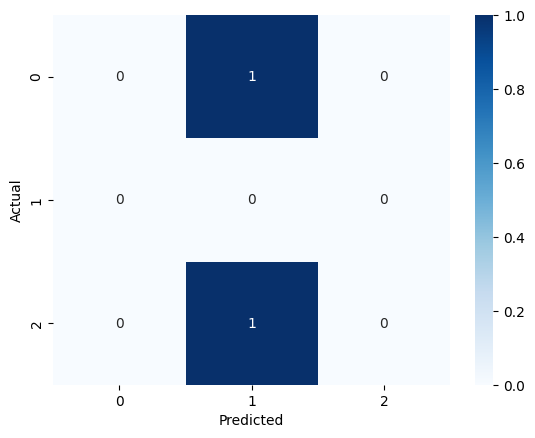

In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
article = [
    "India defeated Australia in the final cricket match."
]
article_vector = vectorizer.transform(article)
prediction = model.predict(article_vector)
print(prediction)

['politics']
